# Campaign group analysis

Load the saved Step 3 graph, IO labels, Random Forest and XGBoost predictions, and node indicators for one campaign. Then build and aggregate the structural and model-specific account groups.

In [1]:
from pathlib import Path

import networkx as nx
import pandas as pd

## Parameters

In [2]:
campaign_name = "Ecuador"

## Locate the saved Step 3 files

This analysis uses the standard Step 3 output with `BERTopic_topic_256` and a top percentage of 100.

In [3]:
def find_project_root(start_path: str | Path) -> Path:
    """Find the project root containing the src and results folders.

    Args:
        start_path: Directory from which to search upward.

    Returns:
        Project root directory.

    Raises:
        FileNotFoundError: If the project root cannot be found.
    """
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "src").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the Backbone-Graph project root.")


project_root = find_project_root(Path.cwd())
topic_col = "BERTopic_topic_256"
top_percentage = 100
dataset_part = f"{campaign_name}_part_all"
step_3_path = (
    project_root
    / "results"
    / "Labeled_Datasets"
    / campaign_name
    / dataset_part
    / "step_3_key_authors_graph"
    / f"topic_col_{topic_col}_top_percentage_{top_percentage:g}"
)
graph_stem = f"accounts_graph_topic_col_{topic_col}"
graph_path = step_3_path / "account_graphs" / f"{graph_stem}.graphml"
node_indicators_path = (
    step_3_path
    / "node_indicators"
    / f"{graph_stem}_node_indicators.parquet"
)
data_path = step_3_path / f"{dataset_part}_step_3.gzip.parquet"
classifier_predictions_paths = {
    model_name: (
        step_3_path
        / "io_classification"
        / (
            f"io_classification_{model_name}_all_indicators_cv_"
            "out_of_fold_predictions.csv"
        )
    )
    for model_name in ["random_forest", "xgboost"]
}

input_paths = {
    "graph": graph_path,
    "node indicators": node_indicators_path,
    "post data": data_path,
    **{
        f"{model_name} predictions": predictions_path
        for model_name, predictions_path in classifier_predictions_paths.items()
    },
}
missing_paths = [path for path in input_paths.values() if not path.is_file()]
if missing_paths:
    missing_text = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(f"Missing Step 3 input files:\n{missing_text}")

pd.DataFrame.from_dict(input_paths, orient="index", columns=["path"])

,path
graph,/home/amitner/Backbone-Graph/results/Labeled_D...
node indicators,/home/amitner/Backbone-Graph/results/Labeled_D...
post data,/home/amitner/Backbone-Graph/results/Labeled_D...
random_forest predictions,/home/amitner/Backbone-Graph/results/Labeled_D...
xgboost predictions,/home/amitner/Backbone-Graph/results/Labeled_D...


In [4]:
# analysis_output_path = project_root / "result" / "group_analysis" / campaign_name
group_analysis_folder_path = step_3_path / "group_analysis"

## Import the group-analysis functions

Definition-only mode imports the functions without running the Step 3 demonstrations or rebuilding data.

In [5]:
starting_directory = Path.cwd()
%cd {project_root / "src"}
key_authors_graph_definition_only = True
%run -i 3_key_authors_graph.ipynb
%cd {starting_directory}


def write_report(msg: str) -> None:
    """Disable progress-report output for this analysis notebook.

    Args:
        msg: Progress message discarded by this notebook.
    """
    print(msg)
    return None

/home/amitner/Backbone-Graph/src
env: NX_CUGRAPH_AUTOCONFIG=False
/home/amitner/Backbone-Graph/src/temp


## Load the graph, labels, predictions, and indicators

In [6]:
G_accounts = nx.read_graphml(graph_path)
node_indicators_df = pd.read_parquet(node_indicators_path)
node_indicators_df.index = node_indicators_df.index.astype(str)
df = pd.read_parquet(
    data_path,
    columns=["accountid", "post_time", topic_col, f"{topic_col}_top_words"],
)

classifier_predictions_by_model = {
    model_name: pd.read_csv(predictions_path, dtype={"author_id": str})
    for model_name, predictions_path in classifier_predictions_paths.items()
}
ground_truth_io_by_model = {
    model_name: set(
        predictions_df.loc[predictions_df["is_io"].eq(1), "author_id"]
    )
    for model_name, predictions_df in classifier_predictions_by_model.items()
}
if len({frozenset(nodes) for nodes in ground_truth_io_by_model.values()}) != 1:
    raise ValueError("Classifier files contain different ground-truth IO labels.")
io_authors_set = next(iter(ground_truth_io_by_model.values()))
classifier_io_authors_by_model = {
    model_name: set(
        predictions_df.loc[
            predictions_df["predicted_is_io"].eq(1),
            "author_id",
        ]
    )
    for model_name, predictions_df in classifier_predictions_by_model.items()
}

load_summary = {
    "graph nodes": G_accounts.number_of_nodes(),
    "graph edges": G_accounts.number_of_edges(),
    "node indicator rows": len(node_indicators_df),
    "ground-truth IO authors": len(io_authors_set),
}
load_summary.update(
    {
        f"{model_name} predicted-IO authors": len(predicted_io_authors)
        for model_name, predicted_io_authors in (
            classifier_io_authors_by_model.items()
        )
    }
)
load_summary_df = pd.Series(load_summary, name="value").to_frame()
load_summary_df.style.format({"value": "{:,}"})

,value
graph nodes,"21,923"
graph edges,"610,106"
node indicator rows,"21,923"
ground-truth IO authors,787
random_forest predicted-IO authors,643
xgboost predicted-IO authors,683


## Group analysis

### All Authors

In [7]:
all_node_group_analysis_df = build_group_analysis(
    nodes=set(G_accounts.nodes),
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model=classifier_io_authors_by_model,
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="all_nodes_group_analysis_results.csv",
)

Starting build_group_analysis: requested_accounts=21,923, graph_nodes=21,923, classifier_models=2
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 177/177 [00:00<00:00, 180.39core/s]


[build_group_analysis] Calculating structural and classifier groups for 21,923 accounts


Calculating account groups: 100%|██████████| 21923/21923 [01:07<00:00, 325.55account/s]


Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,0002e64fc6035627e87f8312ee9c8c0098b1d6cd2a,maximal_k_core_component,core=17|component=0002e64fc6035627e87f8312ee9c...,18,0.000000,5.555556
1,0002e64fc6035627e87f8312ee9c8c0098b1d6cd2a,direct_neighbors,account=0002e64fc6035627e87f8312ee9c8c0098b1d6...,19,5.263158,5.263158
2,0002e64fc6035627e87f8312ee9c8c0098b1d6cd2a,louvain_community,community=101,2506,0.199521,2.753392
3,0002e64fc6035627e87f8312ee9c8c0098b1d6cd2a,same_top_topic,topic=17,205,1.463415,100.000000
4,0002e64fc6035627e87f8312ee9c8c0098b1d6cd2a,classifier_predicted_io_random_forest,classifier_io|model=random_forest,643,97.511664,0.000000


Completed: build_group_analysis


Starting aggregate_and_plot_group_analysis: rows=131,538, eligible_rows=117,059, group_types=6, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,maximal_k_core_component,861,46.762431,4.656669,58.966471
1,direct_neighbors,18726,65.818274,20.092065,58.533247
2,louvain_community,33,6916.722510,3.517216,42.457601
3,same_top_topic,44,8148.185610,3.775546,100.000000
4,classifier_predicted_io_random_forest,1,643.000000,97.511664,22.974497
5,classifier_predicted_io_xgboost,1,683.000000,95.021962,23.736217


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_non_aggregated_scatter.png


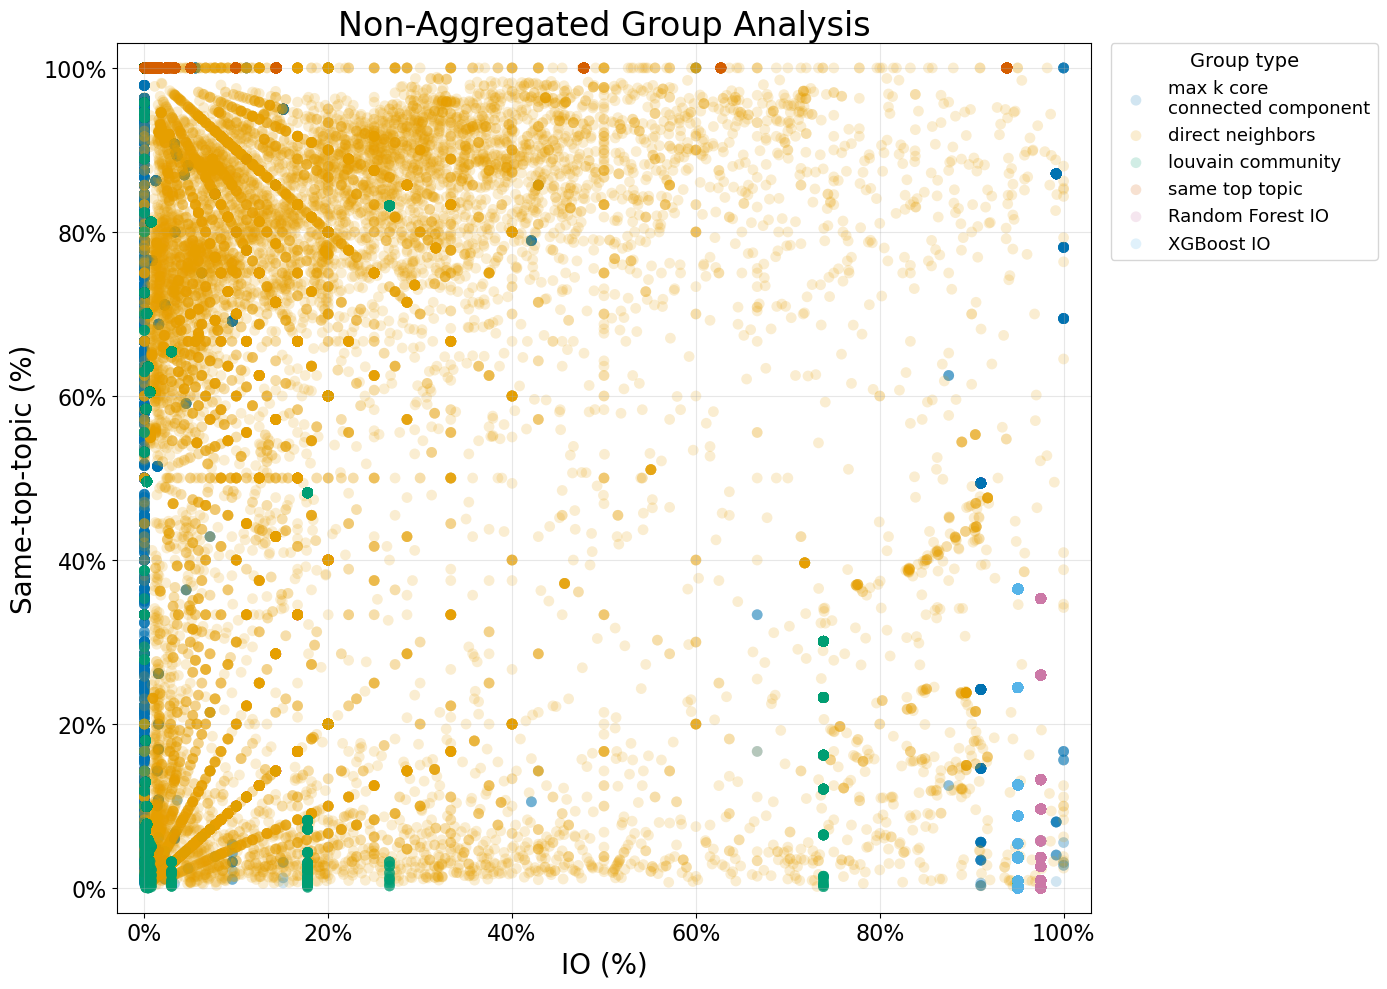

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_aggregate_scatter.png


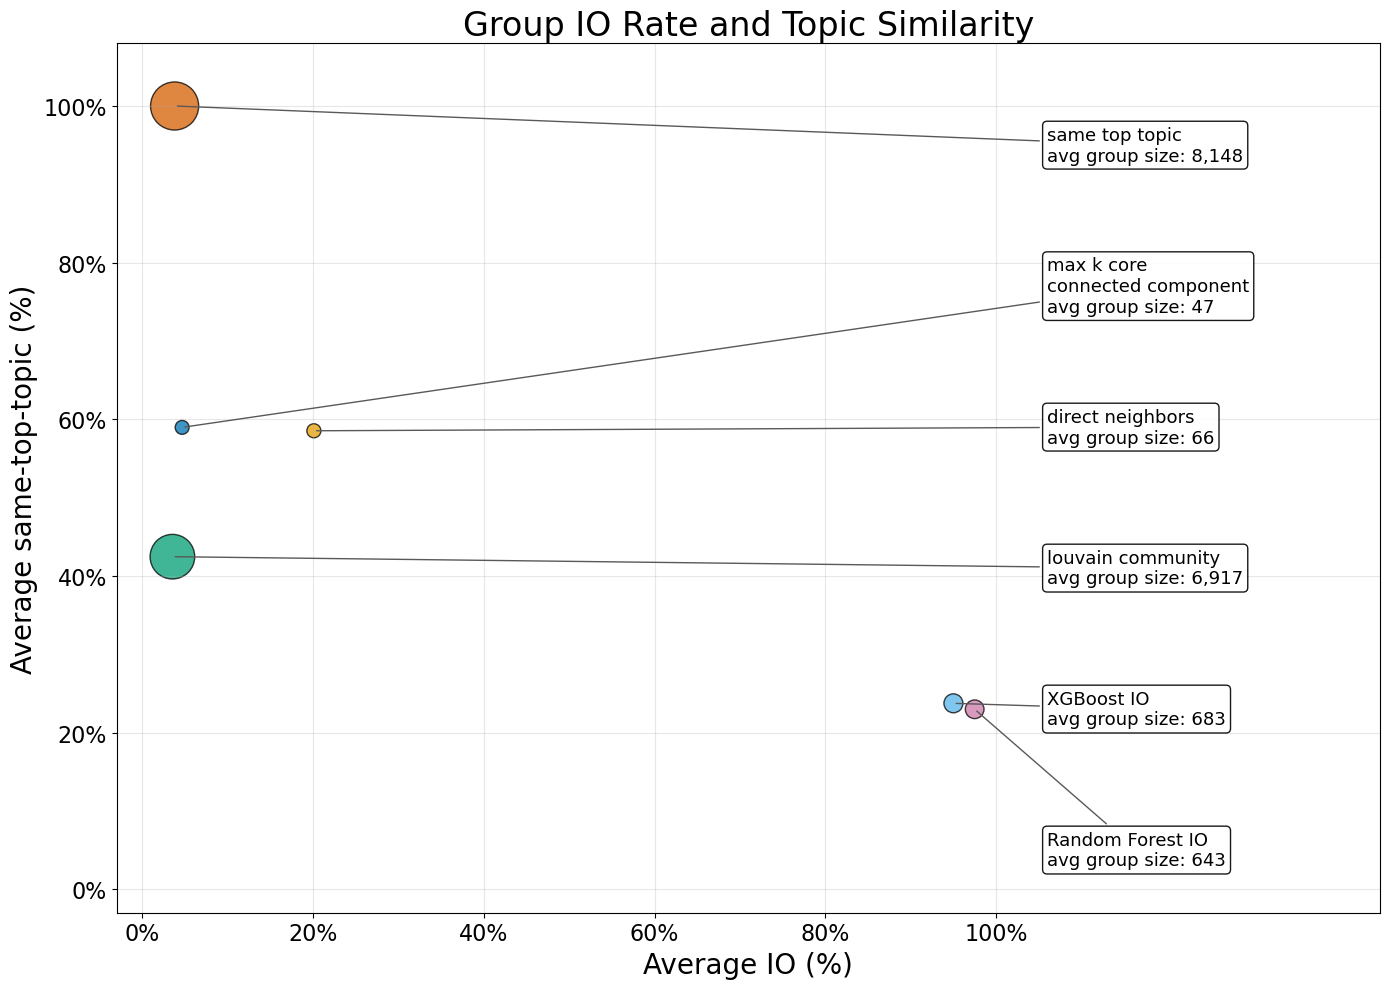

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_combined_scatter.png


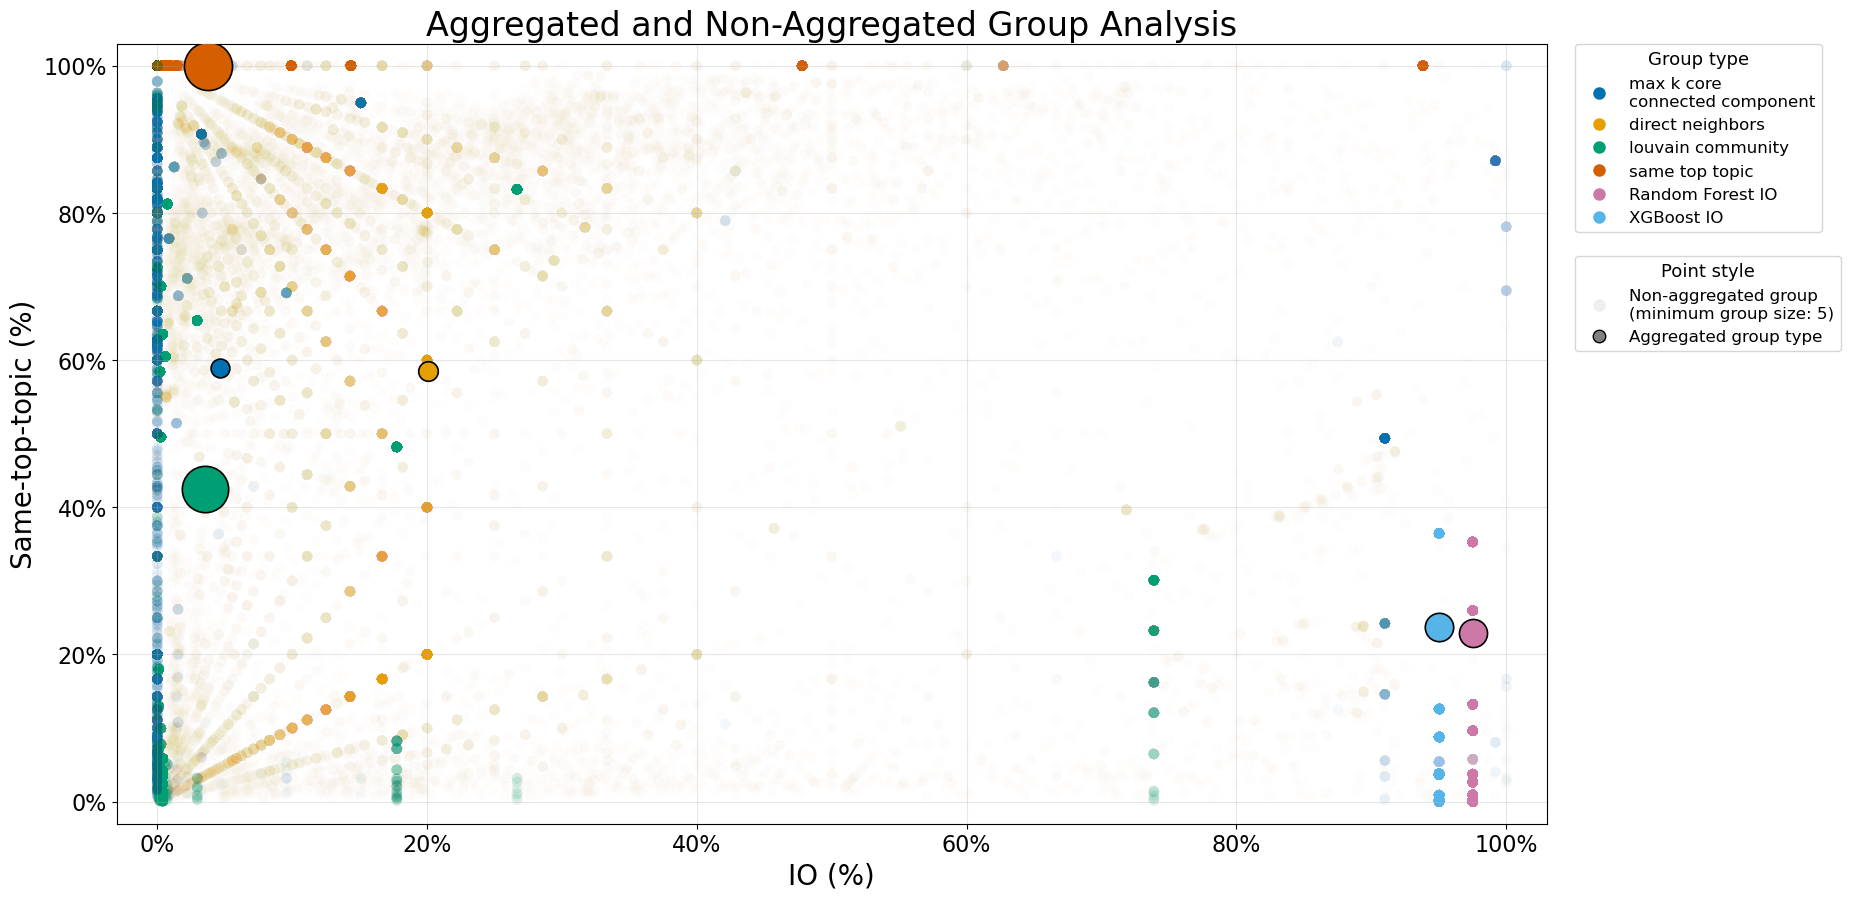

Completed: aggregate_and_plot_group_analysis


In [8]:
group_analysis_aggregate_df = aggregate_and_plot_group_analysis(
    group_analysis_df=all_node_group_analysis_df,
    output_path=group_analysis_folder_path,
    file_name_prefix="all_nodes",
)

### Random Forest predicted-IO authors

Starting build_group_analysis: requested_accounts=643, graph_nodes=21,923, classifier_models=1
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 63/63 [00:00<00:00, 251.46core/s]


[build_group_analysis] Calculating structural and classifier groups for 643 accounts


Calculating account groups: 100%|██████████| 643/643 [00:00<00:00, 749.04account/s]

Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,0020fd099682638e5e7817bc2b0da196a35b29eae6,maximal_k_core_component,core=277|component=0020fd099682638e5e7817bc2b0...,322,90.993789,3.416149
1,0020fd099682638e5e7817bc2b0da196a35b29eae6,direct_neighbors,account=0020fd099682638e5e7817bc2b0da196a35b29...,436,79.816514,8.486239
2,0020fd099682638e5e7817bc2b0da196a35b29eae6,louvain_community,community=68,555,73.873874,6.486486
3,0020fd099682638e5e7817bc2b0da196a35b29eae6,same_top_topic,topic=42,59,62.711864,100.000000
4,0020fd099682638e5e7817bc2b0da196a35b29eae6,classifier_predicted_io_random_forest,classifier_io|model=random_forest,643,97.511664,5.754277


Completed: build_group_analysis
Starting aggregate_and_plot_group_analysis: rows=3,215, eligible_rows=3,103, group_types=5, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,maximal_k_core_component,22,214.395349,86.493850,51.656438
1,direct_neighbors,635,521.669291,71.868829,43.552984
2,louvain_community,10,834.850394,53.512838,33.913516
3,same_top_topic,14,4731.212361,37.735720,100.000000
4,classifier_predicted_io_random_forest,1,643.000000,97.511664,22.863065


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_non_aggregated_scatter.png


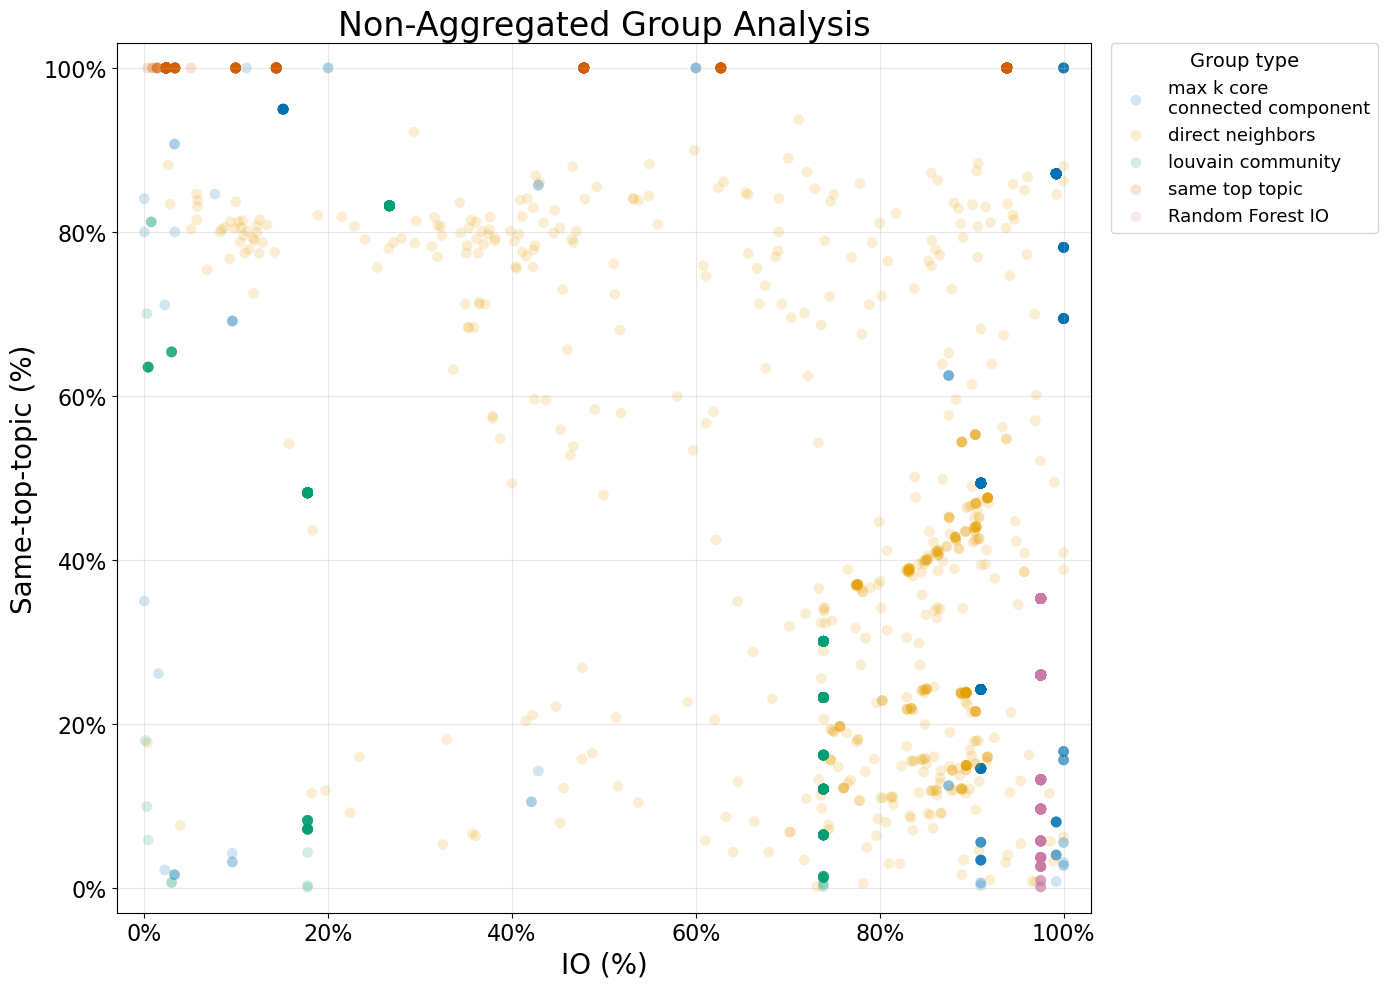

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_aggregate_scatter.png


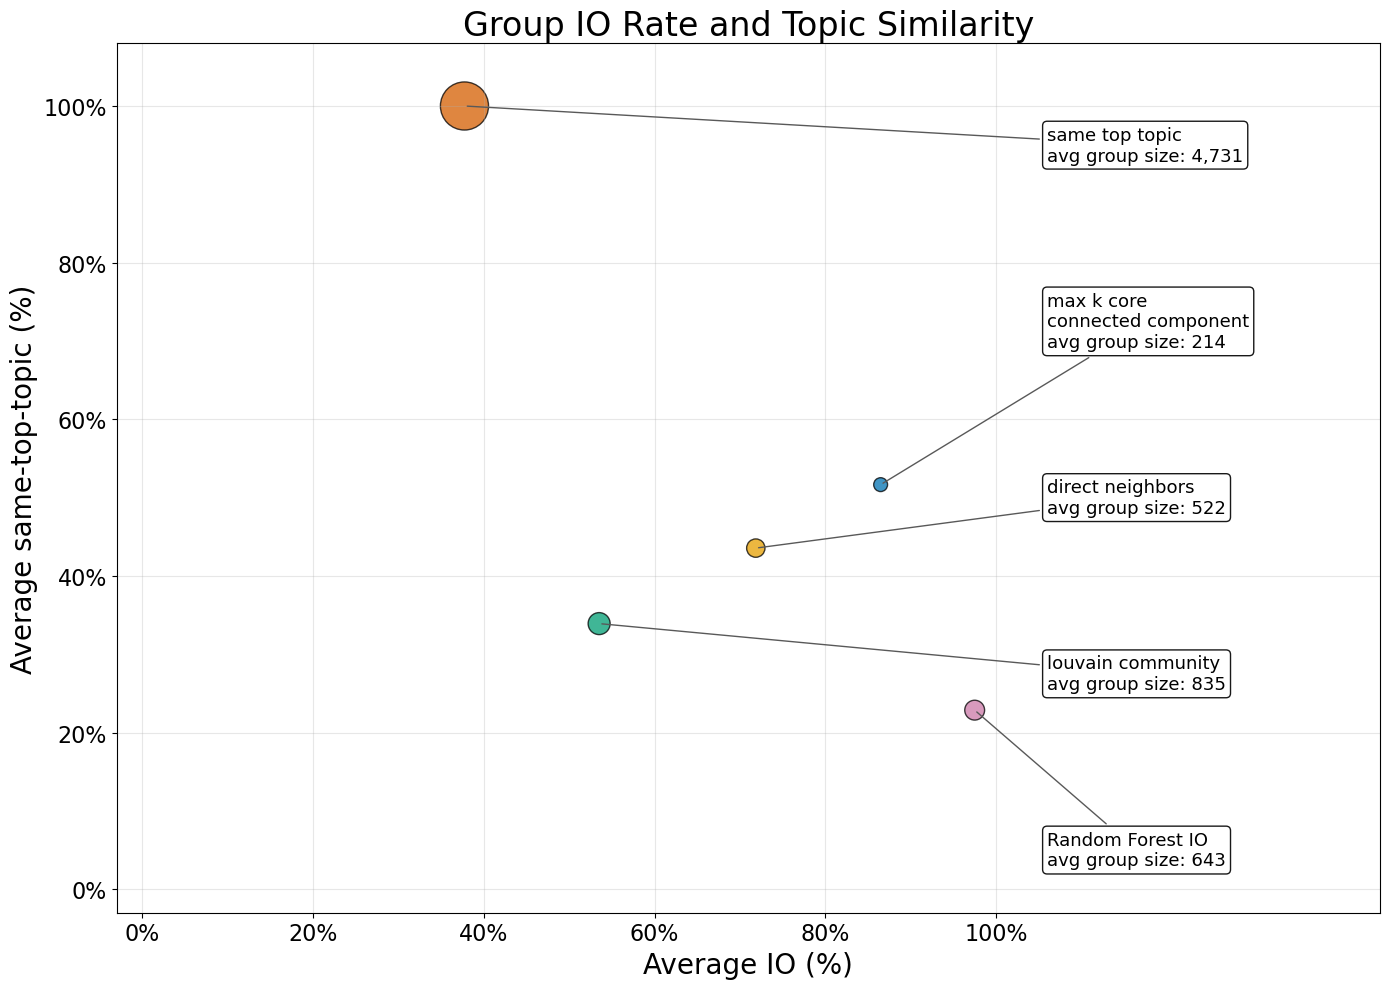

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_combined_scatter.png


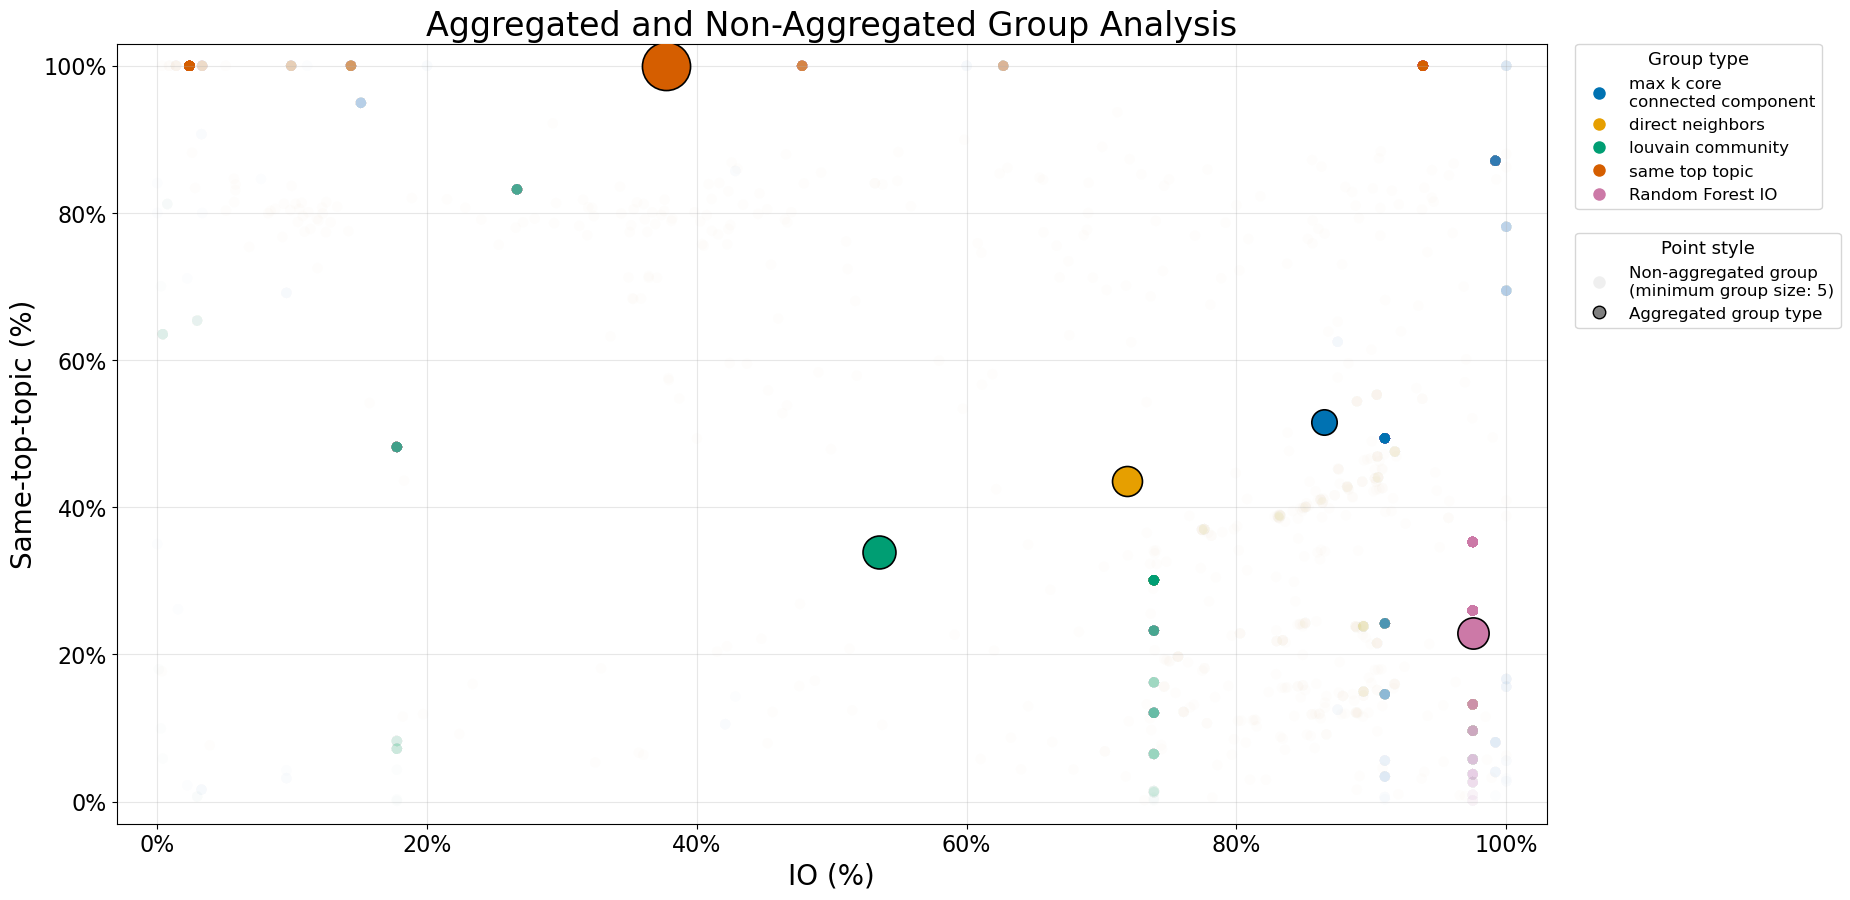

Completed: aggregate_and_plot_group_analysis


In [9]:
rf_io_authors_group_analysis_df = build_group_analysis(
    nodes=classifier_io_authors_by_model["random_forest"],
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model={
        "random_forest": classifier_io_authors_by_model["random_forest"]
    },
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="rf_io_authors_group_analysis_results.csv",
)

rf_io_authors_group_analysis_aggregate_df = aggregate_and_plot_group_analysis(
    group_analysis_df=rf_io_authors_group_analysis_df,
    output_path=group_analysis_folder_path,
    file_name_prefix="rf_io_authors",
)

### XGBoost predicted-IO authors

Starting build_group_analysis: requested_accounts=683, graph_nodes=21,923, classifier_models=1
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 77/77 [00:00<00:00, 226.51core/s]


[build_group_analysis] Calculating structural and classifier groups for 683 accounts


Calculating account groups: 100%|██████████| 683/683 [00:00<00:00, 727.49account/s]

Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,0020fd099682638e5e7817bc2b0da196a35b29eae6,maximal_k_core_component,core=277|component=0020fd099682638e5e7817bc2b0...,322,90.993789,3.416149
1,0020fd099682638e5e7817bc2b0da196a35b29eae6,direct_neighbors,account=0020fd099682638e5e7817bc2b0da196a35b29...,436,79.816514,8.486239
2,0020fd099682638e5e7817bc2b0da196a35b29eae6,louvain_community,community=68,555,73.873874,6.486486
3,0020fd099682638e5e7817bc2b0da196a35b29eae6,same_top_topic,topic=42,59,62.711864,100.000000
4,0020fd099682638e5e7817bc2b0da196a35b29eae6,classifier_predicted_io_xgboost,classifier_io|model=xgboost,683,95.021962,5.417277


Completed: build_group_analysis
Starting aggregate_and_plot_group_analysis: rows=3,415, eligible_rows=3,262, group_types=5, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,maximal_k_core_component,23,211.876543,85.941292,51.723889
1,direct_neighbors,670,501.695522,72.502250,43.780586
2,louvain_community,8,869.811940,52.213019,33.809181
3,same_top_topic,19,4875.372024,35.622284,100.000000
4,classifier_predicted_io_xgboost,1,683.000000,95.021962,22.575908


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_non_aggregated_scatter.png


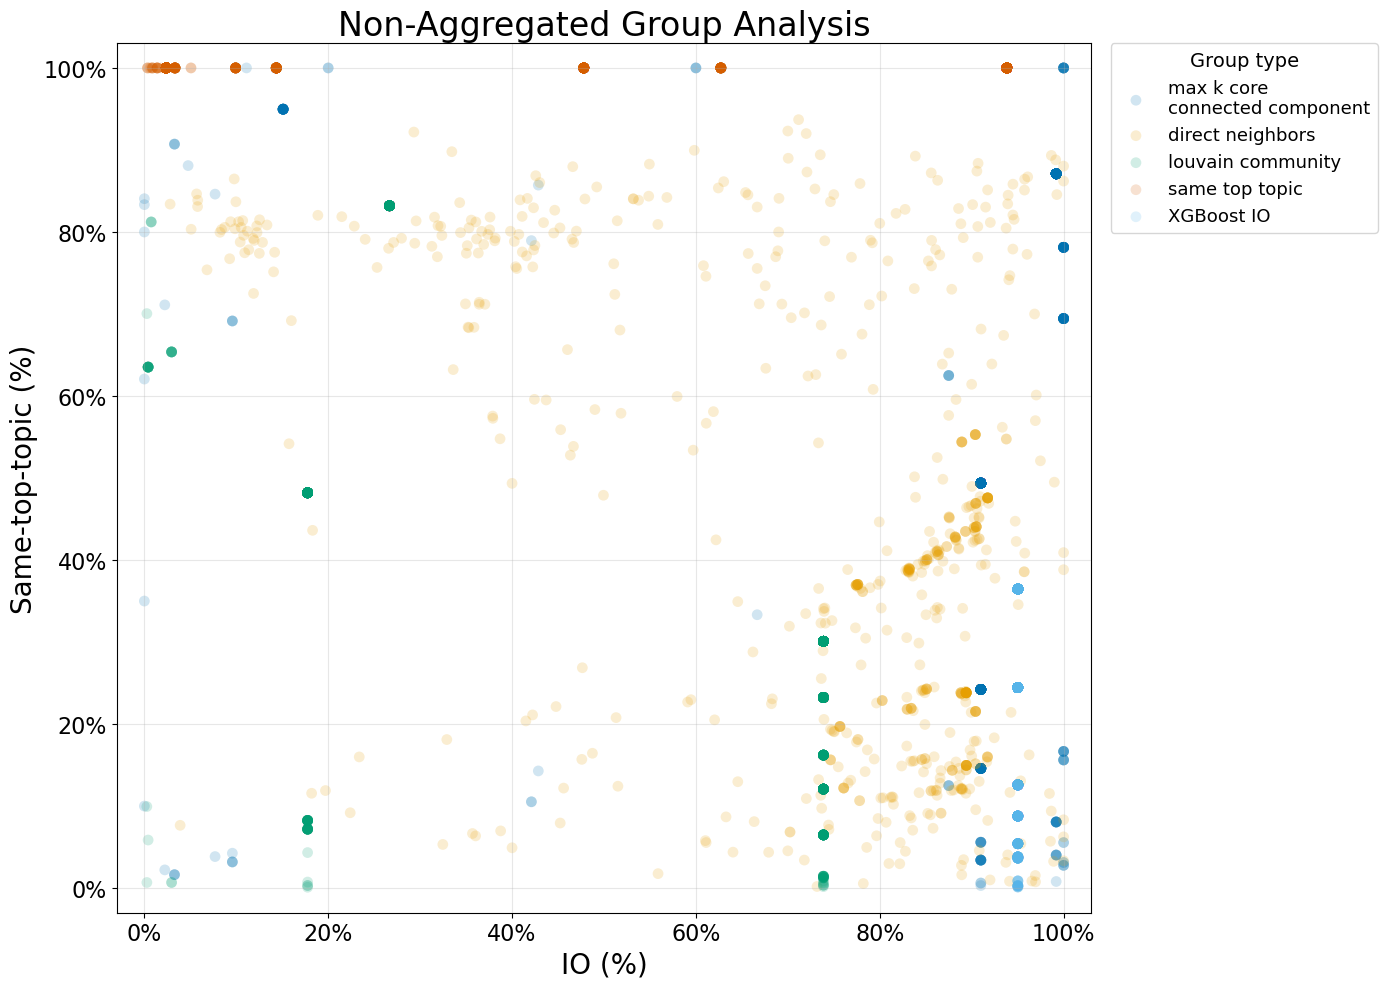

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_aggregate_scatter.png


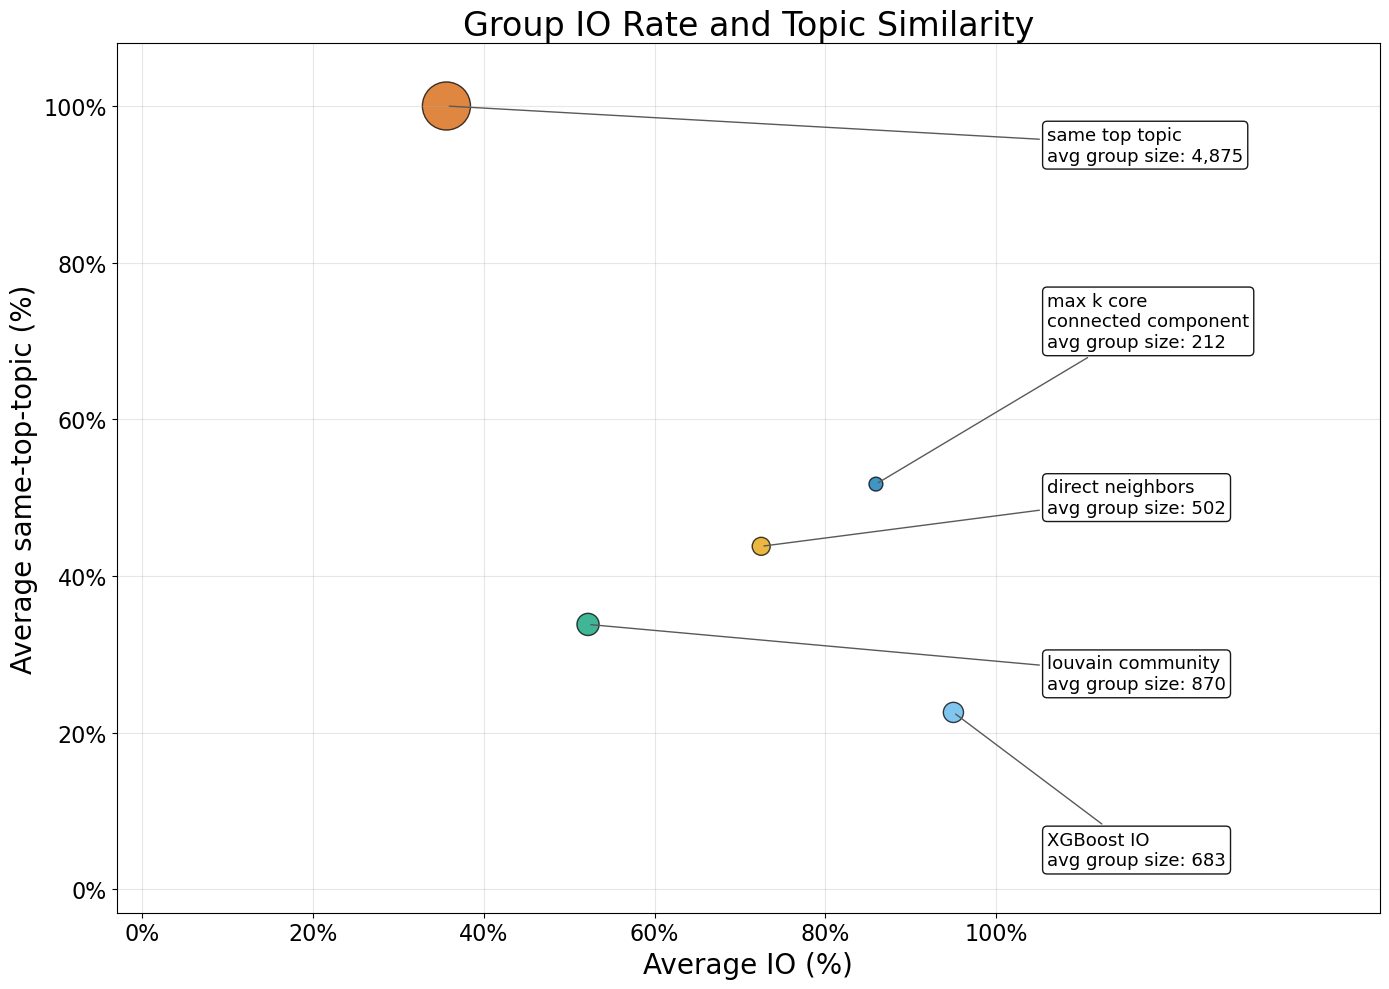

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_combined_scatter.png


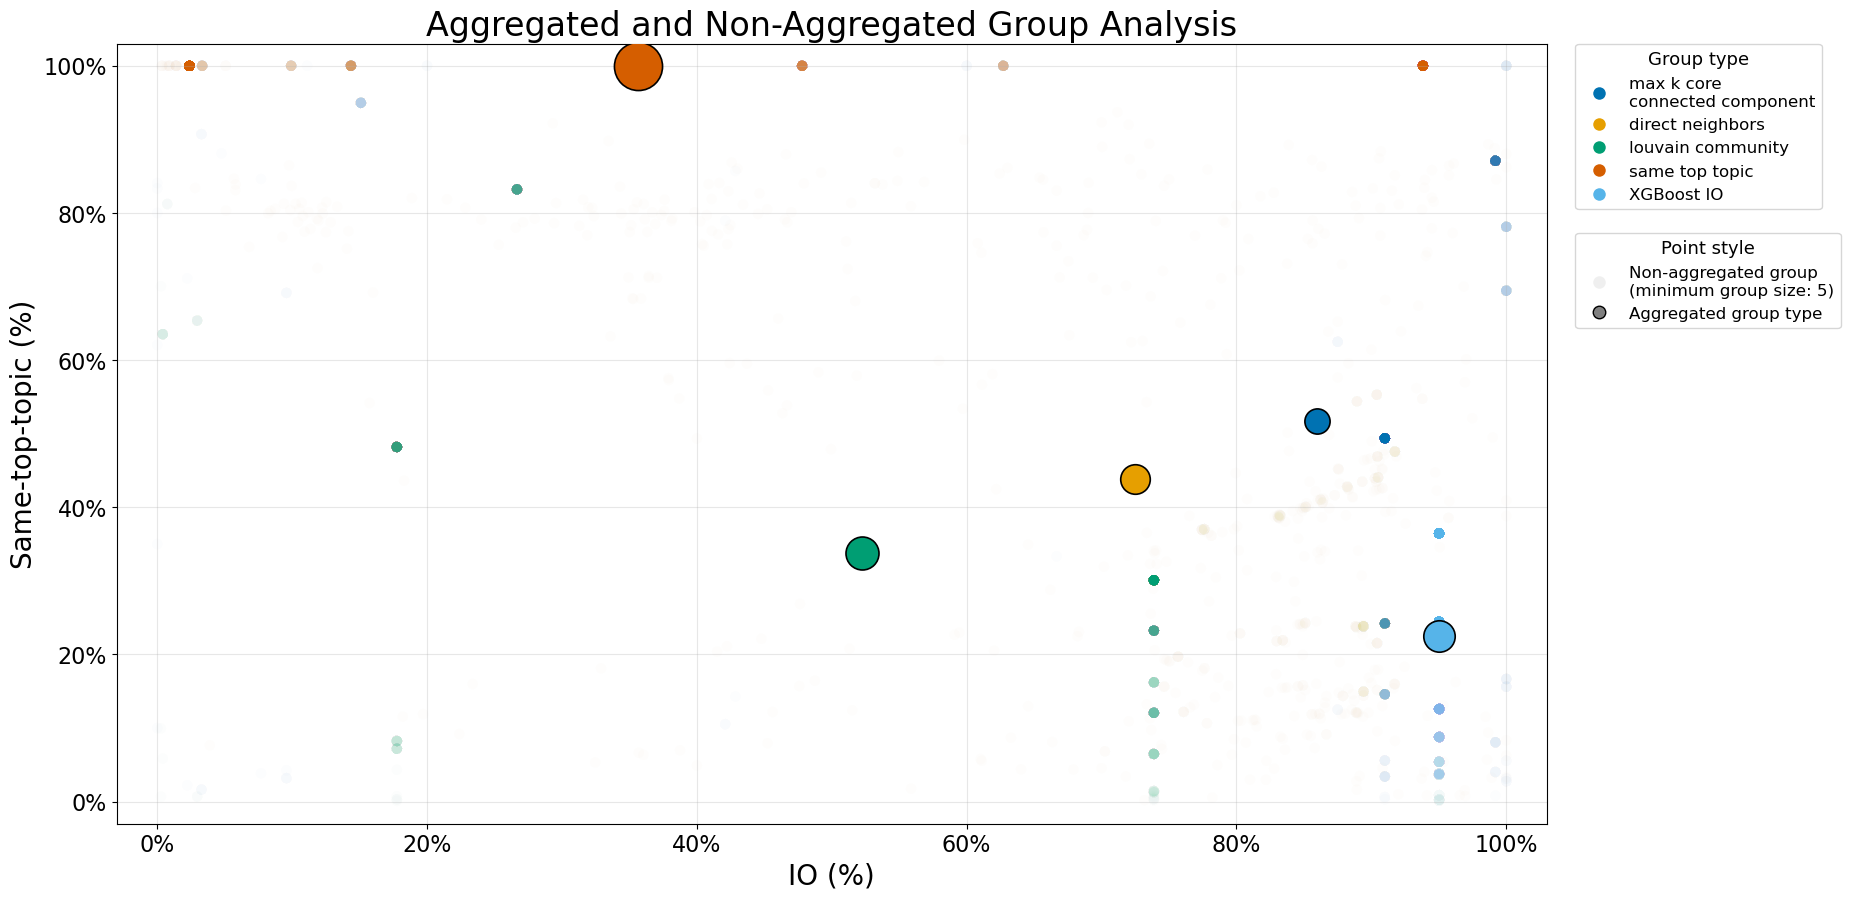

Completed: aggregate_and_plot_group_analysis


In [10]:
xgb_io_authors_group_analysis_df = build_group_analysis(
    nodes=classifier_io_authors_by_model["xgboost"],
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model={
        "xgboost": classifier_io_authors_by_model["xgboost"]
    },
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="xgb_io_authors_group_analysis_results.csv",
)

xgb_io_authors_group_analysis_aggregate_df = (
    aggregate_and_plot_group_analysis(
        group_analysis_df=xgb_io_authors_group_analysis_df,
        output_path=group_analysis_folder_path,
        file_name_prefix="xgb_io_authors",
    )
)

## Analyze Group Topics

In [11]:
top_core_authors_df = get_top_authors_by_indicator(
    node_indicators_df,
    indicator_col="core_number",
    n=10,
)
top_core_user = top_core_authors_df.index[0]

core_numbers = nx.core_number(G_accounts)
top_core_user_k_core_nodes = get_node_k_core(
    node_id=top_core_user,
    G=G_accounts,
    core_numbers=core_numbers,
    include_node=False,
)

print(top_core_user_k_core_nodes)

Starting get_top_authors_by_indicator: authors=21,923, indicator_col=core_number, top_n=10
keep is set to 'first', meaning: prioritize the first occurrences when values are tied.
Completed: get_top_authors_by_indicator
Starting get_node_k_core: node_id=0020fd099682638e5e7817bc2b0da196a35b29eae6, nodes=21,923, include_node=False
[get_node_k_core] Node '0020fd099682638e5e7817bc2b0da196a35b29eae6' is in k-core 277 with 322 nodes.
{'4d2d0d89b5fc6fc5186a51632d13f6b450cbb29ce6', 'e80bd77ec3e727947600748c2f8b848711e7839b8c', 'e9a9d9483a8f66290c072429ede8eda405e6b99d79', 'dde720f6e7893d2126436b6a7e742a485a05c5b05c', 'ce0013f544ae9dde330a49c8f2dd6d819e7e4501ac', '2526c6c3a84e1d757160b60a318c9ff86c0f2fef45', '14b9fb87af9191565fc18e1004550003645709200c', 'd27530c222d84f55bfc7f7b74d58ccdc2459f26f99', '4afc3eb57f08f6349b948147e197705761b6206538', '92596e15ed71dc12b6a969e6ae89682612f55860e1', '74965467b0d324f19a47074b69402bdd2a8de5985d', '59ac852ae91c7acaeeaea77d09f87c72a444e7889a', 'c4fd8d7d6d55742

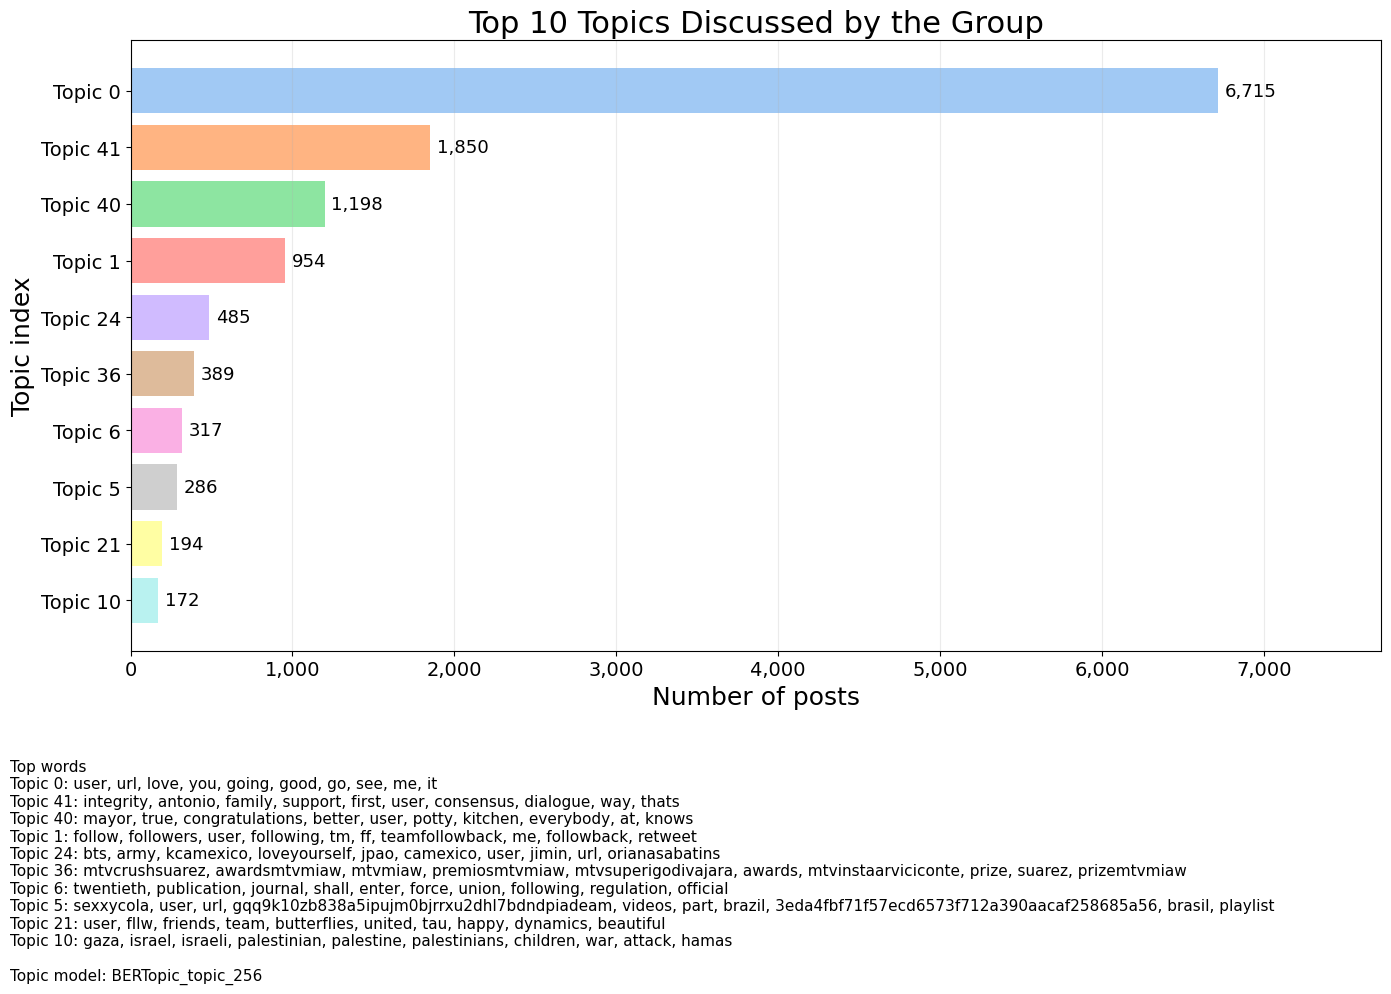

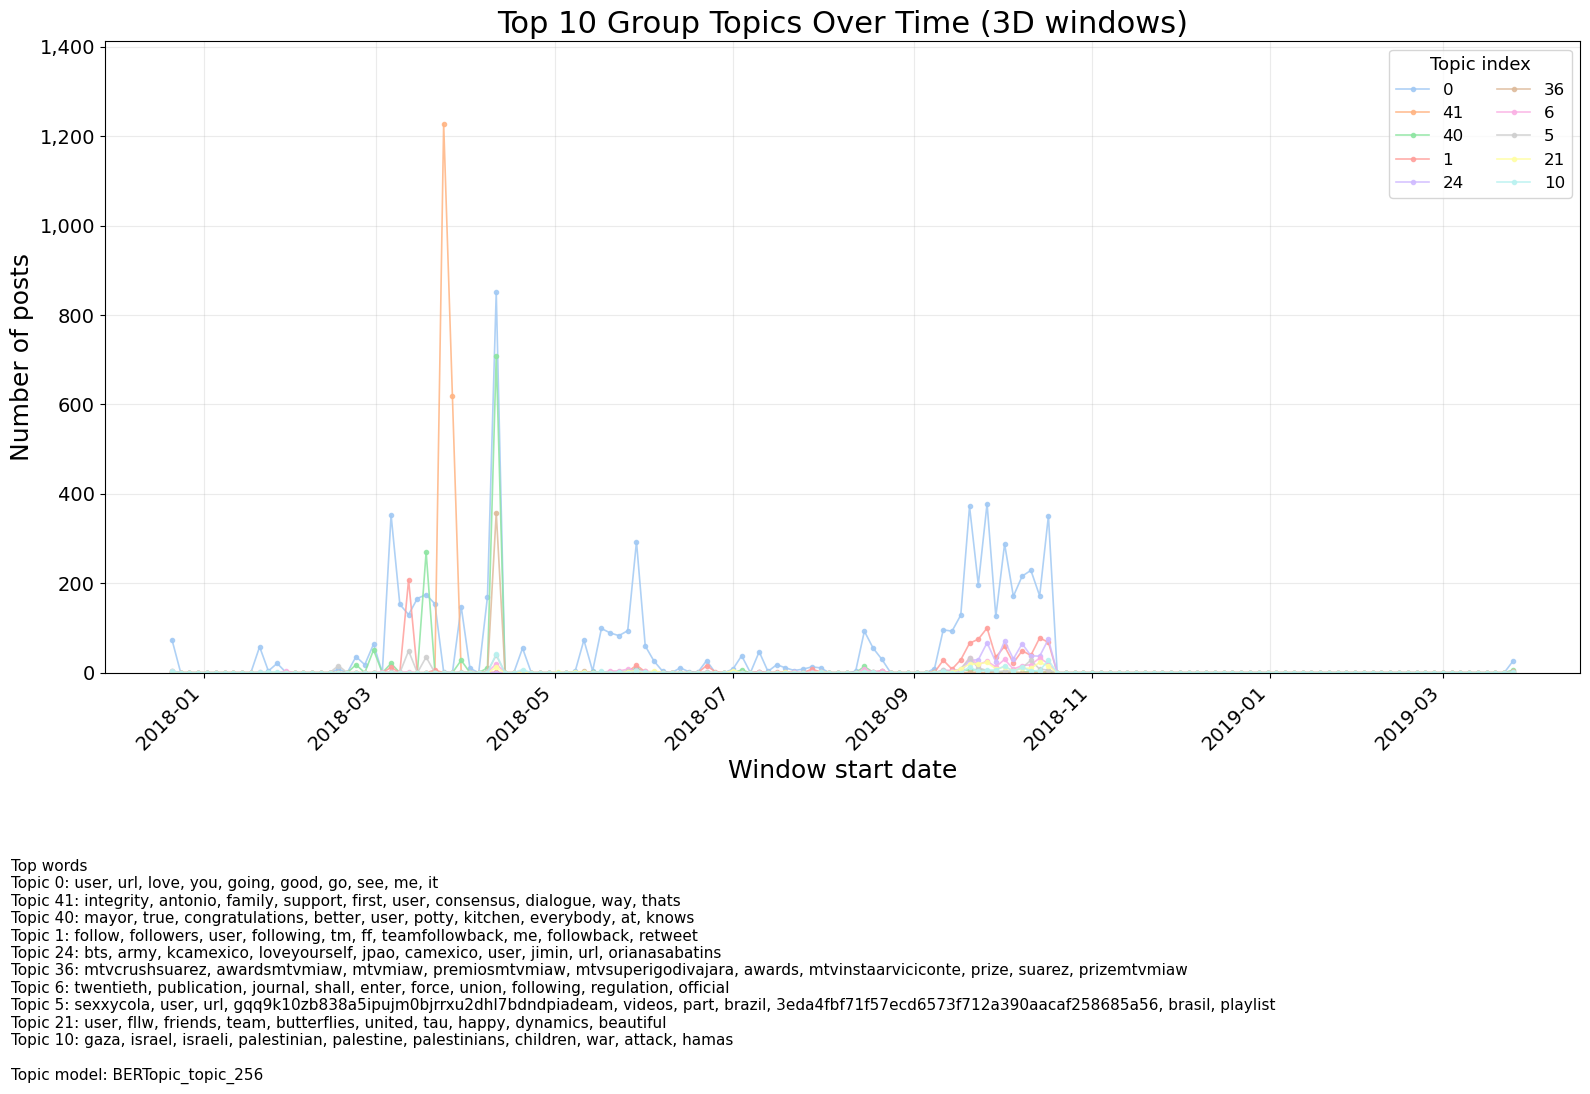

Saved temporal topic counts to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topic_counts_BERTopic_topic_256_3D.csv
Saved topic distribution plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topic_distribution_BERTopic_topic_256.png
Saved temporal topic plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topics_over_time_BERTopic_topic_256_3D.png


,start_date,end_date,BERTopic_topic_256,post_count,topic_top_words
0,2017-12-21,2017-12-24,0,74,"user, url, love, you, going, good, go, see, me..."
1,2017-12-21,2017-12-24,6,4,"twentieth, publication, journal, shall, enter,..."
2,2017-12-21,2017-12-24,10,4,"gaza, israel, israeli, palestinian, palestine,..."
3,2017-12-21,2017-12-24,36,3,"mtvcrushsuarez, awardsmtvmiaw, mtvmiaw, premio..."
4,2017-12-21,2017-12-24,7,2,"god, mercury, gosh, thank, much, help, goll, g..."
5,2017-12-21,2017-12-24,40,2,"mayor, true, congratulations, better, user, po..."
6,2017-12-21,2017-12-24,8,1,"eggs, egg, lay, hatching, theyre, laid, put, u..."
7,2017-12-21,2017-12-24,15,1,"interesting, write, this, actually, aps, doesn..."
8,2017-12-21,2017-12-24,17,1,"iphones, coincidence, writing, type, theme, la..."
9,2018-01-20,2018-01-23,0,58,"user, url, love, you, going, good, go, see, me..."


Completed: analyze_group_topics


In [12]:
group_topic_counts_df = analyze_group_topics(
    df=df,
    nodes=top_core_user_k_core_nodes,
    time_window="3D",
    topic_col=topic_col,
    output_path=group_analysis_folder_path / "top_core_user_k_core_group_topics",
)